### Merge ISPU Data and Formating

In [52]:
import pandas as pd
import os
import re

# CONFIG
FOLDER_PATH = "data/ISPU"
OUTPUT_PATH = "data/ISPU/ispu_dki_2010_2025.csv"

FILES_WITH_YEAR = {
    "data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2024.csv": 2024,
    "data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2025.csv": 2025,
}

COLUMN_MAPPING = {
    "lokasi_spku": "stasiun",

    "pm_sepuluh": "pm10",
    "pm_10": "pm10",

    "pm_duakomalima": "pm2.5",
    "pm25": "pm2.5",

    "sulfur_dioksida": "so2",
    "nitrogen_dioksida": "no2",
    "karbon_monoksida": "co",
    "ozon": "o3",

    "categori": "kategori",
    "parameter_pencemar_kritis": "critical"
}

REQUIRED_COLUMNS = ["pm10", "pm2.5", "so2", "no2", "co", "o3"]

# HELPERS
def clean_tanggal(x):
    if pd.isna(x):
        return pd.NaT

    try:
        x = float(x)
        if x > 30000:
            return pd.to_datetime(x, unit="D", origin="1899-12-30")
    except:
        pass

    return pd.to_datetime(x, dayfirst=True, errors="coerce")


def clean_stasiun(x):
    if pd.isna(x):
        return pd.NA

    x = str(x).upper().strip()

    match = re.search(r"DKI\s*([1-5])", x)
    if match:
        return f"DKI{match.group(1)}"

    return pd.NA

def clean_missing_symbols(df: pd.DataFrame, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    for col in df.columns:
        if col in exclude_cols:
            continue

        df[col] = df[col].replace(
            to_replace=r"^\s*-+\s*$",  
            value=pd.NA,
            regex=True
        )

    return df

def process_ispu(df: pd.DataFrame, year: int | None = None) -> pd.DataFrame:
    df = df.copy()

    df.columns = df.columns.str.lower().str.strip()
    df.rename(columns=COLUMN_MAPPING, inplace=True)

    if {"bulan", "tanggal"}.issubset(df.columns) and year is not None:
        df["year"] = year
        df.rename(columns={"bulan": "month", "tanggal": "day"}, inplace=True)

        df["tanggal"] = pd.to_datetime(
            df[["year", "month", "day"]],
            errors="coerce"
        )

        df.drop(columns=["year", "month", "day"], inplace=True)

    if "tanggal" in df.columns:
        df["tanggal"] = (
            df["tanggal"]
            .apply(clean_tanggal)
            .dt.date
        )

    df = clean_missing_symbols(df, exclude_cols=["tanggal"])

    for col in REQUIRED_COLUMNS:
        if col not in df.columns:
            df[col] = pd.NA
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "stasiun" in df.columns:
        df["stasiun"] = df["stasiun"].apply(clean_stasiun)

    return df

# MAIN PIPELINE
dfs = []

for file in os.listdir(FOLDER_PATH):
    if not file.endswith(".csv"):
        continue
    if file == os.path.basename(OUTPUT_PATH):
        continue  

    path = os.path.join(FOLDER_PATH, file)
    df_raw = pd.read_csv(path)

    year = FILES_WITH_YEAR.get(file)  
    df_clean = process_ispu(df_raw, year)
    dfs.append(df_clean)


# concat semua
df_all = pd.concat(dfs, ignore_index=True)

df_all["tanggal"] = pd.to_datetime(df_all["tanggal"], errors="coerce")

df_all = (
    df_all
    .sort_values(["tanggal", "stasiun"])
    .reset_index(drop=True)
)

df_all.to_csv(OUTPUT_PATH, index=False)

print("Selesai Merge ISPU")


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pa

Selesai Merge ISPU


### Merge Cuaca

In [53]:
from pathlib import Path

data_cuaca_path = Path("data/cuaca-harian")

dfs = []

for file_path in data_cuaca_path.glob("cuaca-harian-dki[1-5]-*.csv"):
    filename = file_path.stem
    stasiun = filename.split("-")[2].strip().upper()  # DKI1–DKI5

    df = pd.read_csv(file_path)

    # ubah nama kolom time -> tanggal
    df = df.rename(columns={"time": "tanggal"})

    # pastikan tanggal bertipe datetime
    df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')

    df['stasiun'] = stasiun
    dfs.append(df)

if not dfs:
    raise ValueError("Tidak ada file DKI1–DKI5 yang terbaca")

df_cuaca_all = pd.concat(dfs, ignore_index=True)

# sorting
stasiun_order = ['DKI1','DKI2','DKI3','DKI4','DKI5']
df_cuaca_all['stasiun'] = pd.Categorical(
    df_cuaca_all['stasiun'],
    categories=stasiun_order,
    ordered=True
)

df_cuaca_all = (
    df_cuaca_all
    .sort_values(['tanggal', 'stasiun'])
    .reset_index(drop=True)
)

output_path = data_cuaca_path / "cuaca-harian-dki-gabungan.csv"
df_cuaca_all.to_csv(output_path, index=False)

print("Selesai. File tersimpan di:", output_path)


Selesai. File tersimpan di: data\cuaca-harian\cuaca-harian-dki-gabungan.csv


### Perbaikan sorted NDVI

In [54]:
df = pd.read_csv("data/NDVI (vegetation index)/indeks-ndvi-jakarta.csv")  

df["tanggal"] = pd.to_datetime(df["tanggal"])

df = df.sort_values(by=["tanggal", "stasiun_id"])

df = df.reset_index(drop=True)

df = df.rename(columns={"stasiun_id": "stasiun"})

df.to_csv("data/NDVI (vegetation index)/ndvi_sorted.csv", index=False)

## Merge data penduduk

In [55]:
data_penduduk_dir = Path("data/jumlah-penduduk")
output_file = data_penduduk_dir / "data_penduduk.csv"

mapping_stasiun = {
    "Jakarta Pusat": "DKI1",
    "Jakarta Utara": "DKI2",
    "Jakarta Selatan": "DKI3",
    "Jakarta Timur": "DKI4",
    "Jakarta Barat": "DKI5",
}

dfs = []

for file_path in data_penduduk_dir.glob("*.csv"):
    if file_path.name == output_file.name:
        continue

    try:
        tahun = int(file_path.stem)
    except ValueError:
        continue

    df = pd.read_csv(file_path, header=None)

    df = df.iloc[:, :2]
    df.columns = ["wilayah", "jumlah_penduduk"]

    df = df.dropna()
    df = df[~df["wilayah"].astype(str).str.contains("kab/kota|0", case=False)]

    df["jumlah_penduduk"] = pd.to_numeric(df["jumlah_penduduk"], errors="coerce")

    df = df[df["wilayah"].isin(mapping_stasiun.keys())]

    df["stasiun"] = df["wilayah"].map(mapping_stasiun)
    df["tahun"] = tahun

    dfs.append(df[["stasiun", "tahun", "jumlah_penduduk"]])

df_penduduk = (
    pd.concat(dfs, ignore_index=True)
      .sort_values(["stasiun", "tahun"])
      .reset_index(drop=True)
)

df_penduduk.to_csv(output_file, index=False, encoding="utf-8")
print(f"Berhasil disimpan di: {output_file}")


Berhasil disimpan di: data\jumlah-penduduk\data_penduduk.csv


### MERGE ISPU, CUACA HARIAN DAN NDVI

In [56]:
BASE_DIR = Path("data")

df_ispu = pd.read_csv(BASE_DIR / "ISPU" / "ispu_dki_2010_2025.csv")
df_cuaca = pd.read_csv(BASE_DIR / "cuaca-harian" / "cuaca-harian-dki-gabungan.csv")
df_ndvi = pd.read_csv(BASE_DIR / "NDVI (vegetation index)" / "ndvi_sorted.csv")
df_libur = pd.read_csv(BASE_DIR / "libur-nasional" / "dataset-libur-nasional-dan-weekend.csv")
df_penduduk = pd.read_csv(BASE_DIR / "jumlah-penduduk" / "data_penduduk.csv")

for df in [df_ispu, df_cuaca, df_ndvi]:
    df["tanggal"] = pd.to_datetime(df["tanggal"])

df_libur["tanggal"] = pd.to_datetime(df_libur["tanggal"])

df_ispu = df_ispu.sort_values(["tanggal", "stasiun"])
df_cuaca = df_cuaca.sort_values(["tanggal", "stasiun"])
df_ndvi = df_ndvi.sort_values(["tanggal", "stasiun"])

df_merge = pd.merge(
    df_ispu,
    df_cuaca,
    on=["tanggal", "stasiun"],
    how="inner"
)

df_merge = pd.merge(
    df_merge,
    df_ndvi,
    on=["tanggal", "stasiun"],
    how="left"
)

df_merge = pd.merge(
    df_merge,
    df_libur,
    on="tanggal",
    how="left"
)

# ambil tahun dari tanggal
df_merge["tahun"] = df_merge["tanggal"].dt.year

df_merge = pd.merge(
    df_merge,
    df_penduduk,
    on=["stasiun", "tahun"],
    how="left"
)

# isi missing penduduk
df_merge = df_merge.sort_values(["stasiun", "tanggal"])

df_merge["jumlah_penduduk"] = (
    df_merge
    .groupby("stasiun")["jumlah_penduduk"]
    .ffill()
    .bfill()
)

df_merge = df_merge.reset_index(drop=True)

if "kategori" in df_merge.columns:
    kolom = [c for c in df_merge.columns if c != "kategori"] + ["kategori"]
    df_merge = df_merge[kolom]

output_path = BASE_DIR / "merged_data.csv"
df_merge.to_csv(output_path, index=False)

print(f"File berhasil disimpan di: {output_path}")


File berhasil disimpan di: data\merged_data.csv


# EDA (Exploratory Data Analysis)

In [57]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [58]:
df = pd.read_csv("data/merged_data.csv")

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\4247355878.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/merged_data.csv")


In [59]:
date_col = "tanggal"   
entity_col = "stasiun"
target_col = "kategori"

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numerik:", num_cols)
print("Kategori:", cat_cols)

Numerik: ['periode_data', 'pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)', 'temperature_2m_mean (°C)', 'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)', 'surface_pressure_mean (hPa)', 'wind_gusts_10m_max (km/h)', 'winddirection_10m_dominant (°)', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'cloud_cover_max (%)', 'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)', 'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)', 'surface_pressure_min (hPa)', 'ndvi', 'is_holiday_nasional', 'is_weekend', 'tahun', 'jumlah_penduduk']
Kategori: ['tanggal', 'stasiun', 'max', 'critical', 'nama_libur', 'day_name', 'kategori']


In [60]:
df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce",
    infer_datetime_format=True
)

if entity_col:
    df = df.sort_values([entity_col, date_col]).reset_index(drop=True)
else:
    df = df.sort_values(date_col).reset_index(drop=True)


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\2543760247.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(


In [61]:
full_range = pd.date_range(
    start=df[date_col].min(),
    end=df[date_col].max(),
    freq="D"   
)

missing_dates = full_range.difference(df[date_col].unique())

print("Jumlah tanggal invalid:", df[date_col].isna().sum())
print("Jumlah tanggal hilang:", len(missing_dates))

dup_rows = df.duplicated(subset=[entity_col, date_col]).sum()
print("Jumlah duplikasi (entitas + tanggal):", dup_rows)

df_dups = df[df.duplicated(subset=[entity_col, date_col], keep=False)]
df_dups.head()

Jumlah tanggal invalid: 0
Jumlah tanggal hilang: 115
Jumlah duplikasi (entitas + tanggal): 215


,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,tahun,jumlah_penduduk,kategori
1083,201610,2016-10-10,DKI1,49.0,NaN,30.0,25.0,21.0,3.0,49,...,1011.2,1007.9,NaN,0,NaN,0,Monday,2016,917754.0,BAIK
1084,201610,2016-10-10,DKI1,54.0,NaN,30.0,31.0,20.0,4.0,54,...,1011.2,1007.9,NaN,0,NaN,0,Monday,2016,917754.0,SEDANG
1116,201611,2016-11-11,DKI1,65.0,NaN,31.0,27.0,27.0,4.0,65,...,1011.8,1007.5,NaN,0,NaN,0,Friday,2016,917754.0,SEDANG
1117,201611,2016-11-11,DKI1,55.0,NaN,31.0,26.0,58.0,4.0,58,...,1011.8,1007.5,NaN,0,NaN,0,Friday,2016,917754.0,SEDANG
1118,201611,2016-11-11,DKI1,62.0,NaN,31.0,31.0,47.0,5.0,62,...,1011.8,1007.5,NaN,0,NaN,0,Friday,2016,917754.0,SEDANG


In [62]:
def is_sequential(group):
    diffs = group[date_col].diff().dropna()
    return diffs.min(), diffs.max()

if entity_col:
    seq_check = df.groupby(entity_col).apply(is_sequential)
else:
    seq_check = is_sequential(df)

print(seq_check)


stasiun
DKI1    (0 days 00:00:00, 245 days 00:00:00)
DKI2     (0 days 00:00:00, 70 days 00:00:00)
DKI3     (0 days 00:00:00, 86 days 00:00:00)
DKI4    (0 days 00:00:00, 108 days 00:00:00)
DKI5    (0 days 00:00:00, 498 days 00:00:00)
dtype: object


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\511690531.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seq_check = df.groupby(entity_col).apply(is_sequential)


In [63]:
display(df.head())
display(df.tail())

df.info()

df.describe().T

,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,tahun,jumlah_penduduk,kategori
0,201001,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73,...,1009.3,1005.1,0.2023,1,New Year's Day,0,Friday,2010,906601.0,SEDANG
1,201002,2010-01-02,DKI1,41.0,NaN,7.0,30.0,17.0,13.0,41,...,1009.9,1006.0,NaN,0,NaN,1,Saturday,2010,906601.0,BAIK
2,201003,2010-01-03,DKI1,60.0,NaN,5.0,39.0,44.0,19.0,60,...,1010.5,1006.5,NaN,0,NaN,1,Sunday,2010,906601.0,SEDANG
3,201004,2010-01-04,DKI1,59.0,NaN,5.0,46.0,NaN,21.0,59,...,1009.1,1005.1,NaN,0,NaN,0,Monday,2010,906601.0,SEDANG
4,201005,2010-01-05,DKI1,60.0,NaN,NaN,24.0,28.0,10.0,60,...,1009.1,1006.0,NaN,0,NaN,0,Tuesday,2010,906601.0,SEDANG


,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,tahun,jumlah_penduduk,kategori
16864,202508,2025-08-27,DKI5,57.0,110.0,25.0,11.0,84.0,46.0,110.0,...,1011.2,1005.6,NaN,0,NaN,0,Wednesday,2025,2470054.0,TIDAK SEHAT
16865,202508,2025-08-28,DKI5,32.0,68.0,25.0,7.0,31.0,28.0,68.0,...,1011.0,1006.7,NaN,0,NaN,0,Thursday,2025,2470054.0,SEDANG
16866,202508,2025-08-29,DKI5,27.0,60.0,24.0,6.0,37.0,27.0,60.0,...,1011.9,1006.9,0.4526,0,NaN,0,Friday,2025,2470054.0,SEDANG
16867,202508,2025-08-30,DKI5,38.0,72.0,26.0,9.0,30.0,40.0,72.0,...,1011.0,1006.7,NaN,0,NaN,1,Saturday,2025,2470054.0,SEDANG
16868,202508,2025-08-31,DKI5,37.0,65.0,25.0,9.0,21.0,34.0,65.0,...,1010.7,1006.9,NaN,0,NaN,1,Sunday,2025,2470054.0,SEDANG


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16869 entries, 0 to 16868
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   periode_data                     16869 non-null  int64         
 1   tanggal                          16869 non-null  datetime64[ns]
 2   stasiun                          16869 non-null  object        
 3   pm10                             14702 non-null  float64       
 4   pm2.5                            6611 non-null   float64       
 5   so2                              15110 non-null  float64       
 6   co                               15203 non-null  float64       
 7   o3                               15066 non-null  float64       
 8   no2                              15099 non-null  float64       
 9   max                              16854 non-null  object        
 10  critical                         15367 non-null  object   

,count,mean,min,25%,50%,75%,max,std
periode_data,16869.0,201813.850258,201001.0,201409.0,201710.0,202304.0,202508.0,482.397224
tanggal,16869,2018-07-26 01:30:29.130357248,2010-01-01 00:00:00,2014-09-17 00:00:00,2017-10-26 00:00:00,2023-04-14 00:00:00,2025-08-31 00:00:00,NaN
pm10,14702.0,54.098218,2.0,42.0,55.0,65.0,187.0,18.952786
pm2.5,6611.0,75.852216,10.0,60.0,77.0,91.0,287.0,24.138489
so2,15110.0,27.907346,0.0,15.0,26.0,38.0,112.0,15.588834
co,15203.0,20.297178,0.0,11.0,18.0,26.0,134.0,12.187505
o3,15066.0,53.443847,2.0,25.0,42.0,71.0,314.0,40.567872
no2,15099.0,17.27631,0.0,10.0,15.0,22.0,202.0,11.559528
temperature_2m_max (°C),16869.0,30.65538,24.1,29.5,30.5,31.8,38.8,1.844864
temperature_2m_min (°C),16869.0,23.571142,18.6,23.0,23.6,24.1,26.4,0.859245


In [64]:
cols_to_drop = ["periode_data", "max", "critical", "ndvi", "nama_libur", "day_name", "tahun"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df.tail()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,jumlah_penduduk,kategori
16864,2025-08-27,DKI5,57.0,110.0,25.0,11.0,84.0,46.0,37.3,24.0,...,16.4,4.6,7.6,1.9,1011.2,1005.6,0,0,2470054.0,TIDAK SEHAT
16865,2025-08-28,DKI5,32.0,68.0,25.0,7.0,31.0,28.0,35.1,24.2,...,20.9,6.1,9.7,2.0,1011.0,1006.7,0,0,2470054.0,SEDANG
16866,2025-08-29,DKI5,27.0,60.0,24.0,6.0,37.0,27.0,33.2,23.8,...,14.7,4.2,6.8,0.4,1011.9,1006.9,0,0,2470054.0,SEDANG
16867,2025-08-30,DKI5,38.0,72.0,26.0,9.0,30.0,40.0,32.7,24.6,...,17.4,5.5,7.9,1.6,1011.0,1006.7,0,1,2470054.0,SEDANG
16868,2025-08-31,DKI5,37.0,65.0,25.0,9.0,21.0,34.0,31.6,23.8,...,14.5,3.6,2.5,0.2,1010.7,1006.9,0,1,2470054.0,SEDANG


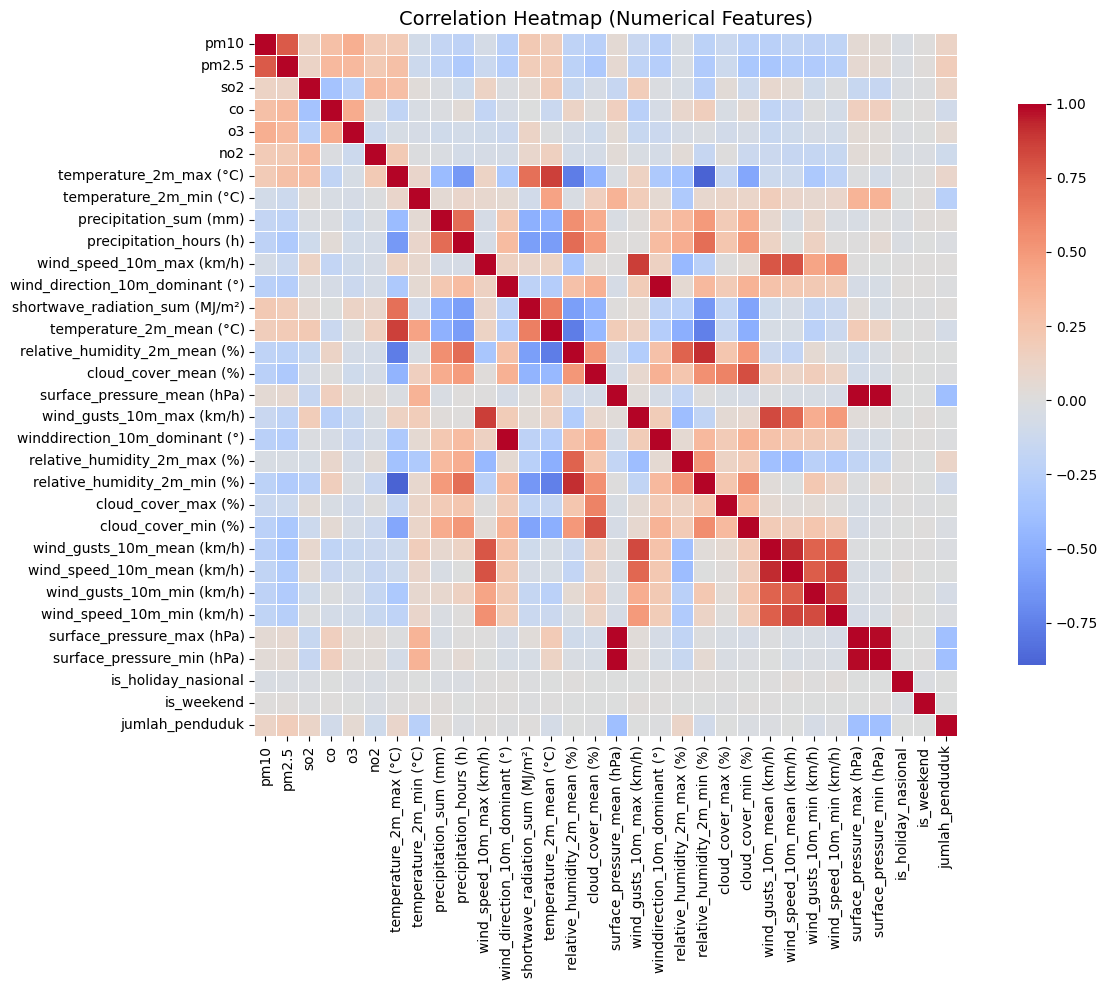

In [65]:
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap (Numerical Features)", fontsize=14)
plt.tight_layout()
plt.show()

In [66]:
df["kategori"] = df["kategori"].replace("TIDAK ADA DATA", np.nan)

df["kategori"].value_counts(dropna=False)

kategori
SEDANG                10446
TIDAK SEHAT            2421
BAIK                   2342
NaN                    1459
SANGAT TIDAK SEHAT      200
BERBAHAYA                 1
Name: count, dtype: int64

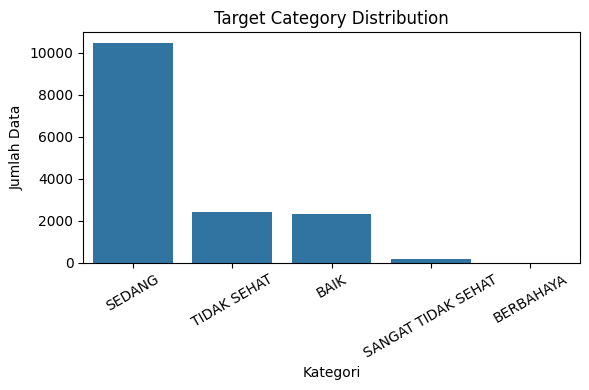

In [67]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target_col,
    order=df[target_col].value_counts().index
)

plt.title("Target Category Distribution")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Target encoding map:
{'BAIK': np.int64(0), 'BERBAHAYA': np.int64(1), 'SANGAT TIDAK SEHAT': np.int64(2), 'SEDANG': np.int64(3), 'TIDAK SEHAT': np.int64(4), nan: np.int64(5)}


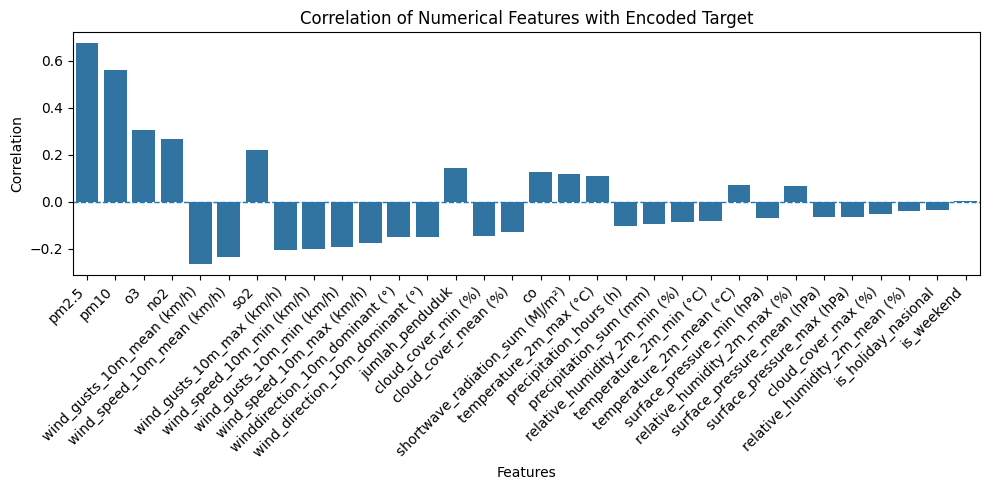

Top 15 features by correlation with target:
                            feature  correlation
0                             pm2.5     0.674420
1                              pm10     0.561609
2                                o3     0.305840
3                               no2     0.267818
4        wind_gusts_10m_mean (km/h)    -0.262922
5        wind_speed_10m_mean (km/h)    -0.235680
6                               so2     0.222577
7         wind_gusts_10m_max (km/h)    -0.206014
8         wind_speed_10m_min (km/h)    -0.198940
9         wind_gusts_10m_min (km/h)    -0.190903
10        wind_speed_10m_max (km/h)    -0.175423
11   winddirection_10m_dominant (°)    -0.149151
12  wind_direction_10m_dominant (°)    -0.149151
13                  jumlah_penduduk     0.142765
14              cloud_cover_min (%)    -0.142668


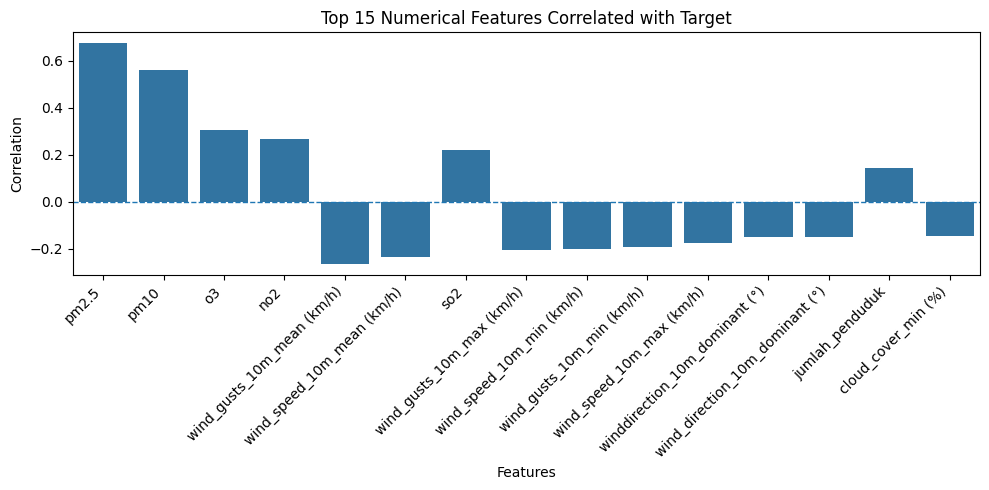

In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["kategori_enc"] = le.fit_transform(df[target_col])

print("Target encoding map:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

num_cols_valid = [c for c in num_cols if c in df.columns]
corr_target = (
    df[num_cols_valid]
    .corrwith(df["kategori_enc"])
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

corr_df = corr_target.reset_index()
corr_df.columns = ["feature", "correlation"]

plt.figure(figsize=(10, 5))
sns.barplot(
    x=corr_df["feature"],
    y=corr_df["correlation"]
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Correlation of Numerical Features with Encoded Target")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Ambil top 15 fitur berdasarkan kekuatan korelasi ---
corr_df["abs_corr"] = corr_df["correlation"].abs()
top15_corr = corr_df.sort_values(by="abs_corr", ascending=False).head(15).drop(columns="abs_corr")

print("Top 15 features by correlation with target:")
print(top15_corr)

plt.figure(figsize=(10, 5))
sns.barplot(
    x="feature",
    y="correlation",
    data=top15_corr
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Top 15 Numerical Features Correlated with Target")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


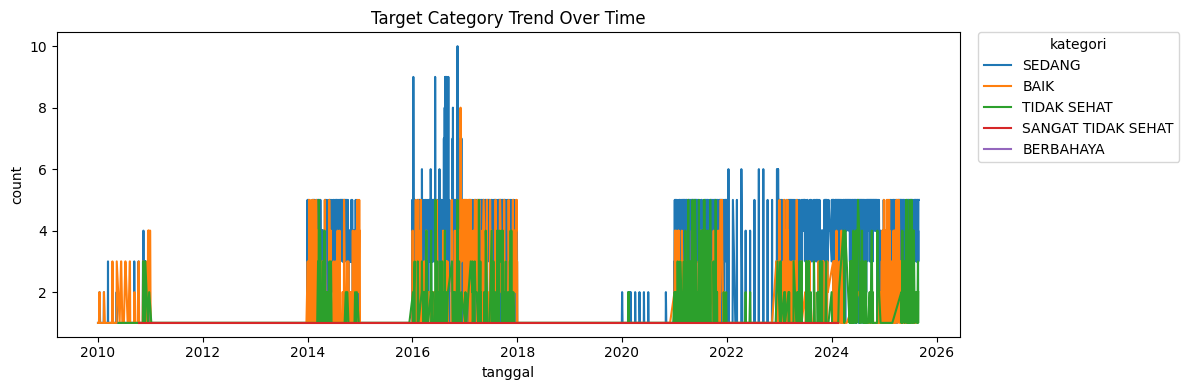

In [73]:
plt.figure(figsize=(12, 4))

target_time = (
    df
    .groupby([date_col, target_col])
    .size()
    .reset_index(name="count")
)

ax = sns.lineplot(
    data=target_time,
    x=date_col,
    y="count",
    hue=target_col
)

plt.title("Target Category Trend Over Time")

# pindahkan legend ke kanan luar
ax.legend(
    title=target_col,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

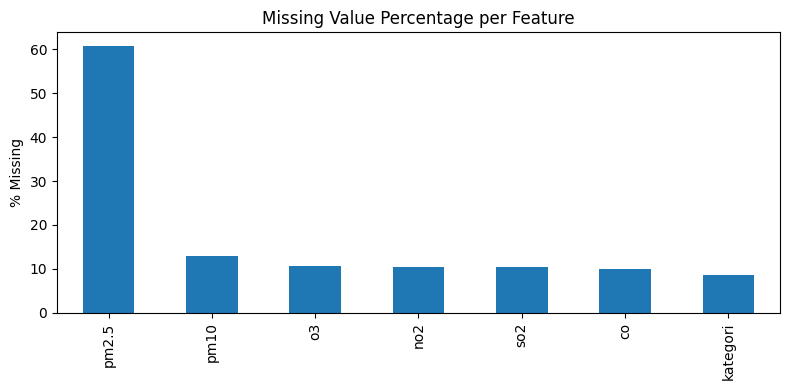

In [74]:
missing_pct = df.isna().mean().mul(100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing_pct.plot(kind="bar")

plt.title("Missing Value Percentage per Feature")
plt.ylabel("% Missing")
plt.tight_layout()
plt.show()

# DATA PREPARATION AND CLEANING

In [75]:
print("Shape:", df.shape)
print("\nKolom:")
print(df.columns)

print("\nHead:")
df.head()

print("\nDescribe (numerik):")
df.describe()

Shape: (16869, 36)

Kolom:
Index(['tanggal', 'stasiun', 'pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2',
       'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)',
       'shortwave_radiation_sum (MJ/m²)', 'temperature_2m_mean (°C)',
       'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)',
       'surface_pressure_mean (hPa)', 'wind_gusts_10m_max (km/h)',
       'winddirection_10m_dominant (°)', 'relative_humidity_2m_max (%)',
       'relative_humidity_2m_min (%)', 'cloud_cover_max (%)',
       'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)',
       'wind_speed_10m_mean (km/h)', 'wind_gusts_10m_min (km/h)',
       'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)',
       'surface_pressure_min (hPa)', 'is_holiday_nasional', 'is_weekend',
       'jumlah_penduduk', 'kategori', 'kategori_enc'],
      dtype='object')

Head:

Describe (numerik):


,tanggal,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),...,wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,jumlah_penduduk,kategori_enc
count,16869,14702.000000,6611.000000,15110.000000,15203.000000,15066.000000,15099.000000,16869.000000,16869.000000,16869.000000,...,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,1.686900e+04,16869.000000
mean,2018-07-26 01:30:29.130357248,54.098218,75.852216,27.907346,20.297178,53.443847,17.276310,30.655380,23.571142,6.991802,...,16.065197,6.441864,6.836689,2.295020,1008.621934,1004.551509,0.045587,0.285672,2.120610e+06,2.888019
min,2010-01-01 00:00:00,2.000000,10.000000,0.000000,0.000000,2.000000,0.000000,24.100000,18.600000,0.000000,...,8.400000,2.200000,0.700000,0.000000,998.900000,995.400000,0.000000,0.000000,9.066010e+05,0.000000
25%,2014-09-17 00:00:00,42.000000,60.000000,15.000000,11.000000,25.000000,10.000000,29.500000,23.000000,1.100000,...,13.000000,4.800000,4.700000,1.000000,1006.700000,1002.600000,0.000000,0.000000,1.764614e+06,3.000000
50%,2017-10-26 00:00:00,55.000000,77.000000,26.000000,18.000000,42.000000,15.000000,30.500000,23.600000,4.400000,...,14.800000,5.800000,6.100000,1.800000,1009.400000,1005.300000,0.000000,0.000000,2.232442e+06,3.000000
75%,2023-04-14 00:00:00,65.000000,91.000000,38.000000,26.000000,71.000000,22.000000,31.800000,24.100000,10.200000,...,17.700000,7.400000,7.900000,2.900000,1011.000000,1006.900000,0.000000,1.000000,2.528065e+06,3.000000
max,2025-08-31 00:00:00,187.000000,287.000000,112.000000,134.000000,314.000000,202.000000,38.800000,26.400000,116.100000,...,45.100000,22.500000,36.000000,18.900000,1015.400000,1011.700000,1.000000,1.000000,3.079618e+06,5.000000
std,NaN,18.952786,24.138489,15.588834,12.187505,40.567872,11.559528,1.844864,0.859245,8.279029,...,4.495879,2.399150,3.413126,1.994611,3.095853,3.070620,0.208593,0.451747,6.566260e+05,1.318577


In [76]:
df = df.drop_duplicates(subset=["tanggal", "stasiun"])
dup_rows = df.duplicated(subset=[entity_col, date_col]).sum()
print("Jumlah duplikasi (entitas + tanggal):", dup_rows)

Jumlah duplikasi (entitas + tanggal): 0


In [77]:
df = df[df["tanggal"].dt.year != 2010]
df["tanggal"].dt.year.value_counts().sort_index()
df = df.sort_values(["tanggal", "stasiun"]).reset_index(drop=True)


In [78]:
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,jumlah_penduduk,kategori,kategori_enc
0,2011-01-01,DKI3,52.0,NaN,17.0,51.0,76.0,7.0,29.6,23.8,...,11.3,11.9,5.7,999.6,995.6,1,1,2141941.0,SEDANG,3
1,2011-01-02,DKI4,56.0,NaN,20.0,22.0,29.0,11.0,30.0,24.1,...,10.4,11.5,4.5,1004.9,1000.9,0,1,2791072.0,SEDANG,3
2,2011-01-03,DKI2,40.0,NaN,14.0,26.0,42.0,8.0,28.0,24.5,...,11.2,12.6,5.4,1008.4,1005.3,0,0,1711036.0,BAIK,0
3,2011-01-04,DKI4,45.0,NaN,14.0,20.0,21.0,8.0,28.4,23.4,...,10.8,9.7,5.4,1004.6,1001.0,0,0,2791072.0,BAIK,0
4,2011-01-05,DKI1,71.0,NaN,18.0,54.0,88.0,31.0,28.0,23.7,...,5.2,6.5,1.1,1007.7,1004.3,0,0,906601.0,SEDANG,3


Interpolasi

In [79]:
cols_interp = ["pm10", "so2", "co", "o3", "no2"]

df = df.sort_values(["stasiun", "tanggal"])

def interpolate_station(x):
    x = x.set_index("tanggal")  
    x = x.interpolate(method="time", limit_direction="both")
    return x.reset_index()

df[cols_interp] = (
    df.groupby("stasiun")[["tanggal"] + cols_interp]
      .apply(interpolate_station)
      .drop(columns="tanggal") 
      .reset_index(drop=True)
)

In [80]:
df["pm2.5"] = df["pm2.5"].fillna(df["pm10"] * 1.5)

In [81]:
df = df.dropna(subset=["kategori"])

In [82]:
df = df.sort_values(["tanggal", "stasiun"]).reset_index(drop=True)
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),is_holiday_nasional,is_weekend,jumlah_penduduk,kategori,kategori_enc
0,2011-01-01,DKI3,71.0,106.5,18.0,54.0,88.0,31.0,29.6,23.8,...,11.3,11.9,5.7,999.6,995.6,1,1,2141941.0,SEDANG,3
1,2011-01-02,DKI4,49.0,73.5,16.0,26.0,44.0,16.0,30.0,24.1,...,10.4,11.5,4.5,1004.9,1000.9,0,1,2791072.0,SEDANG,3
2,2011-01-03,DKI2,35.0,52.5,15.0,15.0,47.0,11.0,28.0,24.5,...,11.2,12.6,5.4,1008.4,1005.3,0,0,1711036.0,BAIK,0
3,2011-01-04,DKI4,41.0,61.5,16.0,35.0,31.0,15.0,28.4,23.4,...,10.8,9.7,5.4,1004.6,1001.0,0,0,2791072.0,BAIK,0
4,2011-01-05,DKI1,69.0,103.5,22.0,31.0,69.0,28.0,28.0,23.7,...,5.2,6.5,1.1,1007.7,1004.3,0,0,906601.0,SEDANG,3


In [83]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14672 entries, 0 to 14671
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tanggal                          14672 non-null  datetime64[ns]
 1   stasiun                          14672 non-null  object        
 2   pm10                             14672 non-null  float64       
 3   pm2.5                            14672 non-null  float64       
 4   so2                              14672 non-null  float64       
 5   co                               14672 non-null  float64       
 6   o3                               14672 non-null  float64       
 7   no2                              14672 non-null  float64       
 8   temperature_2m_max (°C)          14672 non-null  float64       
 9   temperature_2m_min (°C)          14672 non-null  float64       
 10  precipitation_sum (mm)           14672 non-null  float64  

tanggal                            0
stasiun                            0
pm10                               0
pm2.5                              0
so2                                0
co                                 0
o3                                 0
no2                                0
temperature_2m_max (°C)            0
temperature_2m_min (°C)            0
precipitation_sum (mm)             0
precipitation_hours (h)            0
wind_speed_10m_max (km/h)          0
wind_direction_10m_dominant (°)    0
shortwave_radiation_sum (MJ/m²)    0
temperature_2m_mean (°C)           0
relative_humidity_2m_mean (%)      0
cloud_cover_mean (%)               0
surface_pressure_mean (hPa)        0
wind_gusts_10m_max (km/h)          0
winddirection_10m_dominant (°)     0
relative_humidity_2m_max (%)       0
relative_humidity_2m_min (%)       0
cloud_cover_max (%)                0
cloud_cover_min (%)                0
wind_gusts_10m_mean (km/h)         0
wind_speed_10m_mean (km/h)         0
w

In [84]:
from sklearn.preprocessing import StandardScaler

df = df.sort_values(["stasiun", "tanggal"]).reset_index(drop=True)

pollutant_cols = ["pm10", "pm2.5", "so2", "no2", "o3", "co"]
binary_cols = ["is_weekend", "is_holiday_nasional"]
target_col_enc = "kategori_enc"
exclude_cols = binary_cols + [target_col_enc, "jumlah_penduduk"]

for col in pollutant_cols:
    df[f"{col}_lag3"] = df.groupby("stasiun")[col].shift(3)

df = (
    df.groupby("stasiun", group_keys=False)
      .apply(lambda x: x.iloc[3:])
      .reset_index(drop=True)
)

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\3910425470.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[3:])


In [85]:
df = df.sort_values(["stasiun", "tanggal"]).reset_index(drop=True)
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,is_weekend,jumlah_penduduk,kategori,kategori_enc,pm10_lag3,pm2.5_lag3,so2_lag3,no2_lag3,o3_lag3,co_lag3
0,2011-03-01,DKI1,-0.153596,-0.064362,-1.710167,1.094857,0.063831,0.070480,-2.148138,-0.324763,...,0,906601.0,BAIK,0,0.787771,0.989260,-0.414858,0.929755,0.383836,0.924908
1,2011-03-05,DKI1,-0.519948,-0.474560,-1.710167,0.677461,-0.034926,-0.186116,-1.560585,0.366201,...,1,906601.0,SEDANG,3,0.578441,0.754917,-0.867938,0.415515,0.803377,1.842308
2,2011-04-22,DKI1,-0.048924,0.052837,-0.998019,0.593982,-0.108993,0.070480,-0.385479,-1.015727,...,0,906601.0,TIDAK SEHAT,4,0.316778,0.461988,-0.803212,0.329808,0.457872,3.593707
3,2011-04-24,DKI1,-1.514331,-1.587952,-1.192241,0.260066,-0.578086,-0.613774,-1.667413,0.481362,...,1,906601.0,SEDANG,3,-0.154214,-0.065284,-1.709372,0.072688,0.063010,1.091708
4,2011-04-25,DKI1,1.625827,1.928024,-1.386463,3.515753,0.162587,0.754734,-1.133274,0.020719,...,0,906601.0,SEDANG,3,-0.520542,-0.475384,-1.709372,-0.184432,-0.035706,0.674708


# LSTM

In [ ]:
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.metrics import f1_score, classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
# from datetime import timedelta

# # ==========================
# # 0. Seed untuk reproducibility
# # ==========================
# SEED = 42
# np.random.seed(SEED)
# import tensorflow as tf
# tf.random.set_seed(SEED)

# # ==========================
# # 1. Pilih fitur & target
# # ==========================
# lstm_features = numeric_cols + binary_cols  # semua fitur numeric + binary
# target_col_enc = "kategori_enc"  # gunakan kolom ini langsung

# # Sort dan reset index
# df = df.sort_values(["stasiun", "tanggal"]).reset_index(drop=True)

# # ==========================
# # 2. Buat windowing / sequence
# # ==========================
# SEQ_LEN = 3
# X_seq, y_seq, dates_seq, stations_seq = [], [], [], []

# for st in df["stasiun"].unique():
#     st_data = df[df["stasiun"] == st]
#     feature_data = st_data[lstm_features].values
#     target_data = st_data[target_col_enc].values
#     date_data = st_data["tanggal"].values
#     for i in range(SEQ_LEN, len(st_data)):
#         # skip jika target missing
#         if pd.isna(target_data[i]):
#             continue
#         X_seq.append(feature_data[i-SEQ_LEN:i])
#         y_seq.append(target_data[i])
#         dates_seq.append(date_data[i])
#         stations_seq.append(st)

# X_seq = np.array(X_seq)
# y_seq = np.array(y_seq)  # langsung pakai kategori_enc
# dates_seq = np.array(dates_seq)
# stations_seq = np.array(stations_seq)

# num_classes = int(y_seq.max() + 1)  # jumlah kelas dari kategori_enc

# # ==========================
# # 3. Split train / val (3 bulan terakhir sebagai val)
# # ==========================
# train_mask = dates_seq < np.datetime64("2025-06-01")
# val_mask   = (dates_seq >= np.datetime64("2025-06-01")) & (dates_seq <= np.datetime64("2025-08-31"))

# X_train, y_train = X_seq[train_mask], y_seq[train_mask]
# X_val, y_val     = X_seq[val_mask], y_seq[val_mask]

# # ==========================
# # 4. Build LSTM model (lebih kompleks + regularization)
# # ==========================
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
# from tensorflow.keras.optimizers import Adam

# lstm_model = Sequential([
#     LSTM(128, input_shape=(SEQ_LEN, X_train.shape[2]), return_sequences=True),
#     Dropout(0.3),
#     BatchNormalization(),
#     LSTM(64, return_sequences=False),
#     Dropout(0.3),
#     Dense(64, activation="relu"),
#     Dropout(0.2),
#     Dense(num_classes, activation="softmax")
# ])

# lstm_model.compile(
#     loss="sparse_categorical_crossentropy",
#     optimizer=Adam(learning_rate=0.001),
#     metrics=["accuracy"]
# )

# # ==========================
# # 5. Training dengan early stopping
# # ==========================
# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# history = lstm_model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=50,
#     batch_size=32,
#     callbacks=[early_stop],
#     verbose=2
# )

# # ==========================
# # 6. Evaluasi validasi
# # ==========================
# from sklearn.metrics import f1_score, classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

# y_pred_val = np.argmax(lstm_model.predict(X_val), axis=1)
# macro_f1 = f1_score(y_val, y_pred_val, average="macro")
# print("Validation Macro F1 Score:", macro_f1)
# print(classification_report(y_val, y_pred_val))

# # Confusion matrix
# cm = confusion_matrix(y_val, y_pred_val)
# plt.figure(figsize=(8,6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Validation Set")
# plt.show()

# # ==========================
# # 7. Forecast future (2025-09-01 s/d 2025-11-30) auto-regressive
# # ==========================
# test_dates = pd.date_range("2025-09-01", "2025-11-30", freq="D")
# submission_rows = []

# stasiun_list = sorted(df["stasiun"].unique(), key=lambda x: int(x.upper().replace("DKI","")))

# for d in test_dates:
#     for st in stasiun_list:
#         st_data = df[df["stasiun"] == st].sort_values("tanggal")
#         last_seq = st_data[lstm_features].values[-SEQ_LEN:].copy()
#         X_input = last_seq[np.newaxis, :, :]
#         y_pred_enc = np.argmax(lstm_model.predict(X_input), axis=1)[0]

#         # inverse transform ke kategori string asli
#         y_pred_label = le.inverse_transform([y_pred_enc])[0]

#         submission_rows.append({
#             "id": f"{d.strftime('%Y-%m-%d')}_{st}",
#             "kategori": y_pred_label  # gunakan nama kategori asli
#         })

#         # Update window auto-regressive
#         next_row = last_seq[-1].copy()
#         last_seq = np.vstack([last_seq[1:], next_row])

# # Buat DataFrame submission
# submission_lstm = pd.DataFrame(submission_rows)
# submission_lstm["stasiun_num"] = submission_lstm["id"].str.extract(r"(?i)dki(\d+)")[0].astype(int)
# submission_lstm = submission_lstm.sort_values(["id", "stasiun_num"]).reset_index(drop=True)
# submission_lstm = submission_lstm.drop(columns="stasiun_num")

# # Simpan CSV
# submission_lstm.to_csv("submission_lstm_forecast.csv", index=False)
# print("File submission_lstm_forecast.csv siap!")


Class weights: {0: np.float64(1.3918250950570341), 1: np.float64(2928.4), 2: np.float64(14.940816326530612), 3: np.float64(0.29322118754380694), 4: np.float64(1.2440101954120646)}


c:\Miniconda3\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
412/412 - 7s - 16ms/step - accuracy: 0.2436 - loss: 2.0296 - val_accuracy: 0.0000e+00 - val_loss: 1.4693
Epoch 2/50
412/412 - 3s - 6ms/step - accuracy: 0.2182 - loss: 2.4074 - val_accuracy: 0.0000e+00 - val_loss: 1.4415
Epoch 3/50
412/412 - 3s - 7ms/step - accuracy: 0.2278 - loss: 2.2934 - val_accuracy: 0.0000e+00 - val_loss: 1.5209
Epoch 4/50
412/412 - 3s - 7ms/step - accuracy: 0.1531 - loss: 2.0985 - val_accuracy: 0.0000e+00 - val_loss: 1.5367
Epoch 5/50
412/412 - 3s - 6ms/step - accuracy: 0.1543 - loss: 2.0381 - val_accuracy: 0.0000e+00 - val_loss: 1.4562
Epoch 6/50
412/412 - 3s - 7ms/step - accuracy: 0.1764 - loss: 1.8997 - val_accuracy: 0.0000e+00 - val_loss: 1.4454
Epoch 7/50
412/412 - 3s - 6ms/step - accuracy: 0.1819 - loss: 2.2203 - val_accuracy: 0.0000e+00 - val_loss: 1.4235
Epoch 8/50
412/412 - 3s - 6ms/step - accuracy: 0.1918 - loss: 2.0010 - val_accuracy: 0.0000e+00 - val_loss: 1.4360
Epoch 9/50
412/412 - 3s - 7ms/step - accuracy: 0.1868 - loss: 2.3670 - val_accu

c:\Miniconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Miniconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Miniconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Miniconda3\envs\ml\lib\site-packages\sklea

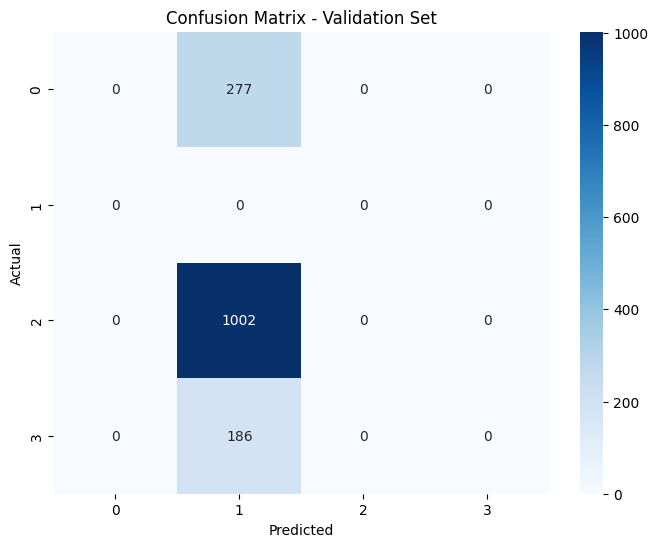

File submission_lstm_forecast.csv siap!


In [86]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# 0. Seed untuk reproducibility
# ==========================
SEED = 42
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

# ==========================
# 1. Tentukan top 15 feature + lag3 jika ada
# ==========================
# top15_corr sudah dibuat sebelumnya
top15_features = top15_corr["feature"].tolist()

# ambil semua lag3 yang ada dari top15_features
lag3_features = [f"{f}_lag3" for f in top15_features if f"{f}_lag3" in df.columns]

# gabungkan top15 + lag3
lstm_features = top15_features + lag3_features

target_col_enc = "kategori_enc"  # kolom target sudah di-encode

# Sort dan reset index
df = df.sort_values(["stasiun", "tanggal"]).reset_index(drop=True)

# ==========================
# 2. Buat windowing / sequence
# ==========================
SEQ_LEN = 3
X_seq, y_seq, dates_seq, stations_seq = [], [], [], []

for st in df["stasiun"].unique():
    st_data = df[df["stasiun"] == st]
    feature_data = st_data[lstm_features].values
    target_data = st_data[target_col_enc].values
    date_data = st_data["tanggal"].values
    for i in range(SEQ_LEN, len(st_data)):
        if pd.isna(target_data[i]):
            continue
        X_seq.append(feature_data[i-SEQ_LEN:i])
        y_seq.append(target_data[i])
        dates_seq.append(date_data[i])
        stations_seq.append(st)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
dates_seq = np.array(dates_seq)
stations_seq = np.array(stations_seq)

num_classes = int(y_seq.max() + 1)

# ==========================
# 3. Hitung class weight
# ==========================
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_seq),
    y=y_seq
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# ==========================
# 4. Split train / val (3 bulan terakhir sebagai val)
# ==========================
num_samples = len(X_seq)
split_idx = int(num_samples * 0.9)

X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_val, y_val     = X_seq[split_idx:], y_seq[split_idx:]

# ==========================
# 5. Build LSTM model (forecasting classification)
# ==========================
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential([
    LSTM(128, input_shape=(SEQ_LEN, X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    BatchNormalization(),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# ==========================
# 6. Training dengan early stopping + class weight
# ==========================
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=2
)

# ==========================
# 7. Evaluasi validasi
# ==========================
y_pred_val = np.argmax(lstm_model.predict(X_val), axis=1)
macro_f1 = f1_score(y_val, y_pred_val, average="macro")
print("Validation Macro F1 Score:", macro_f1)
print(classification_report(y_val, y_pred_val))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Validation Set")
plt.show()


test_dates = pd.date_range("2025-09-01", "2025-11-30", freq="D")
submission_rows = []

stasiun_list = sorted(df["stasiun"].unique(), key=lambda x: int(x.upper().replace("DKI","")))

for d in test_dates:
    for st in stasiun_list:
        st_data = df[df["stasiun"] == st].sort_values("tanggal")
        last_seq = st_data[lstm_features].values[-SEQ_LEN:].copy()
        
        # Prediksi auto-regressive
        X_input = last_seq[np.newaxis, :, :]
        y_pred_enc = np.argmax(lstm_model.predict(X_input, verbose=0), axis=1)[0]

        # inverse transform ke kategori string asli
        y_pred_label = le.inverse_transform([y_pred_enc])[0]

        submission_rows.append({
            "id": f"{d.strftime('%Y-%m-%d')}_{st}",
            "kategori": y_pred_label
        })

        # Update window auto-regressive: tambahkan prediksi ke sequence jika perlu
        next_row = last_seq[-1].copy()  # tetap pakai feature terakhir, lag tidak diperbarui karena prediksi target
        last_seq = np.vstack([last_seq[1:], next_row])

# Buat DataFrame submission
submission_lstm = pd.DataFrame(submission_rows)
submission_lstm["stasiun_num"] = submission_lstm["id"].str.extract(r"(?i)dki(\d+)")[0].astype(int)
submission_lstm = submission_lstm.sort_values(["id", "stasiun_num"]).reset_index(drop=True)
submission_lstm = submission_lstm.drop(columns="stasiun_num")

# Simpan CSV
submission_lstm.to_csv("submission_lstm_3.csv", index=False)
print("File submission_lstm_forecast.csv siap!")
